In [1]:
import pandas as pd

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,Lasso,ElasticNet,Ridge
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix,r2_score,mean_squared_error

from matplotlib import pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [2]:
housing_data = fetch_california_housing()

housing_data_df = pd.DataFrame(data=housing_data.data,columns=housing_data.feature_names)

In [3]:
housing_data_df["Target"] = housing_data.target

In [4]:
housing_data_df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [5]:
X=pd.DataFrame(housing_data.data,columns=housing_data.feature_names)
y=housing_data.target

In [6]:
X= X.head(300)
y=y[:300]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,shuffle=True,random_state=42)

### Models for regularization

In [8]:
linear_model =LinearRegression()
lasso_model =Lasso(alpha=1.0)
ridge_model = Ridge(alpha=0.1)
elastic_model = ElasticNet(alpha=1.0)

In [9]:
linear_model.fit(X_train,y_train)
lasso_model.fit(X_train,y_train)
ridge_model.fit(X_train,y_train)
elastic_model.fit(X_train,y_train)

,alpha,1.0
,l1_ratio,0.5
,fit_intercept,True
,precompute,False
,max_iter,1000
,copy_X,True
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [10]:

print("Linear Regression Coefficients")
print(linear_model.coef_)

print("Ridge Regression Coefficients")
print(ridge_model.coef_)

print("Lasso Regression Coefficients")
print(lasso_model.coef_)

print("Elastic Net Coefficients")
print(elastic_model.coef_)

Linear Regression Coefficients
[ 3.15272236e-01 -1.19102829e-03 -2.19710959e-02 -1.16047844e+00
  8.46147260e-05 -5.86095640e-02  1.24102102e+01  2.81208607e+00]
Ridge Regression Coefficients
[ 3.59327178e-01 -1.15833662e-03 -1.03305948e-03 -1.45427434e+00
  9.46005720e-05 -1.03172686e-01  4.44238215e+00 -1.37035015e+00]
Lasso Regression Coefficients
[ 1.2211304e-01 -0.0000000e+00  0.0000000e+00 -0.0000000e+00
  3.7397850e-05 -0.0000000e+00  0.0000000e+00  0.0000000e+00]
Elastic Net Coefficients
[ 2.23980811e-01 -1.55867629e-03  0.00000000e+00 -0.00000000e+00
  5.14863619e-05 -0.00000000e+00  0.00000000e+00  0.00000000e+00]


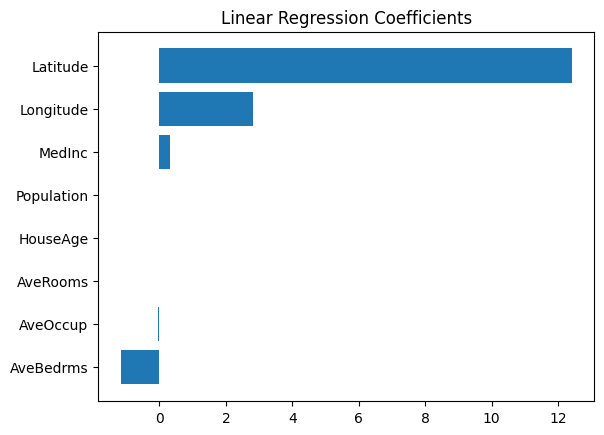

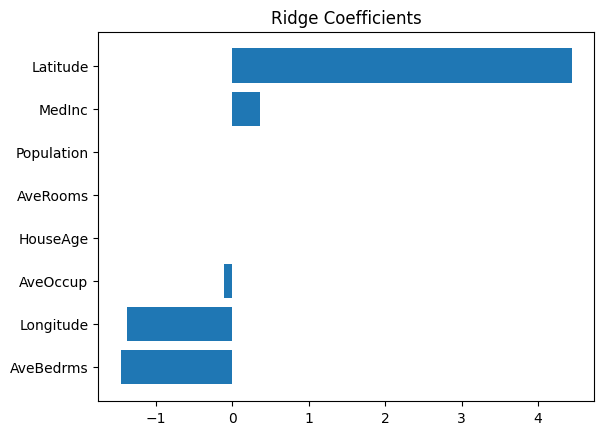

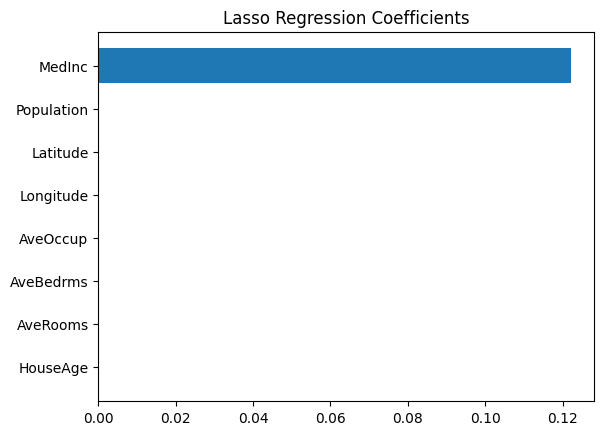

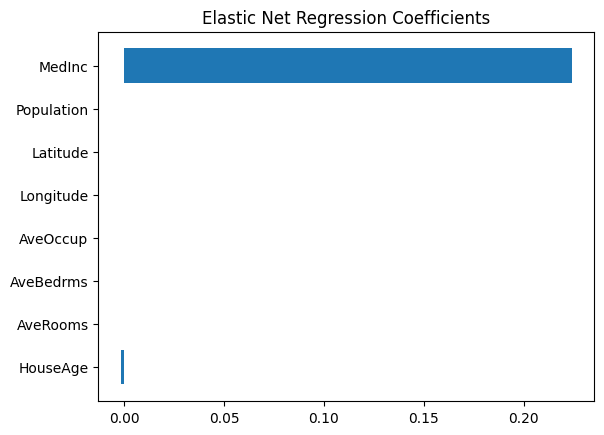

In [11]:
def plot_Coefficient(model,feature,title):
    
    coeff_df = pd.DataFrame({"Coefficient":model.coef_,
                             "feature_name":feature})

    coeff_df = coeff_df.sort_values(by="Coefficient")
   
    plt.barh(coeff_df["feature_name"],coeff_df["Coefficient"])
    plt.title(title)
    plt.show()
    
plot_Coefficient(
    linear_model,
    X.columns,
    "Linear Regression Coefficients"
)    

plot_Coefficient(
    ridge_model,
    X.columns,
    "Ridge Coefficients"
)

plot_Coefficient(
    lasso_model,
    X.columns,
    "Lasso Regression Coefficients"
)


plot_Coefficient(
    elastic_model,
    X.columns,
    "Elastic Net Regression Coefficients"
)

In [19]:
models = {
    "Linear_model":linear_model,
    "Lasso_model":lasso_model,
    "Ridge_model":ridge_model,
    "Elasticnet_model":elastic_model
}

for name, model_obj in models.items():

    print("Model Name:",name)

    y_pred_train = model_obj.predict(X_train)

    y_pred_test = model_obj.predict(X_test)

    print("Training Report:")

    print("MSE:",mean_squared_error(y_train,y_pred_train))
    print("r2:",r2_score(y_train,y_pred_train))

    print("Test Report:")

    # mean squared errors - average of squared error making the mistake look bigger
    print("MSE:",mean_squared_error(y_test,y_pred_test))
    
    #r2 - How well your model understands the pattern (0–1) 1 is good 
    print("r2:",r2_score(y_test,y_pred_test),"\n")


Model Name: Linear_model
Training Report:
MSE: 0.2582417657930333
r2: 0.7152275943106212
Test Report:
MSE: 0.2037414994033127
r2: 0.5267289231638961 

Model Name: Lasso_model
Training Report:
MSE: 0.606120414631624
r2: 0.33160940066361744
Test Report:
MSE: 0.3311095529411062
r2: 0.23086570418843988 

Model Name: Ridge_model
Training Report:
MSE: 0.27041554452779076
r2: 0.7018031343051646
Test Report:
MSE: 0.1949005093900728
r2: 0.5472656566036582 

Model Name: Elasticnet_model
Training Report:
MSE: 0.43975530462041007
r2: 0.5150661411145054
Test Report:
MSE: 0.26103850226388164
r2: 0.39363372987868406 



## **Interview Format Explanation**

### **Interviewer:** Can you explain the common evaluation metrics used in linear regression?

### **You (Candidate):**  
Sure. In linear regression, we mainly use **error-based metrics** and **variance-explained metrics** to evaluate how well the model predicts continuous values.

---

## ⭐ **1. MAE — Mean Absolute Error**  
**“MAE tells me the average amount by which my predictions are off.”**

It calculates the average of the absolute differences between actual and predicted values.  
It’s easy to interpret because it’s in the same units as the target variable.  
MAE treats all errors equally, so it’s less sensitive to outliers.

---

## ⭐ **2. MSE — Mean Squared Error**  
**“MSE squares the errors, so larger mistakes are punished more.”**

It takes the average of squared differences between actual and predicted values.  
Because errors are squared, MSE is very sensitive to outliers.  
It’s commonly used during model training because it’s smooth and differentiable.

---

## ⭐ **3. RMSE — Root Mean Squared Error**  
**“RMSE is the square root of MSE, so it brings the error back to the original units.”**

RMSE is often preferred because it’s interpretable like MAE but still penalizes large errors like MSE.  
It’s one of the most widely used regression metrics.

---

## ⭐ **4. R² — Coefficient of Determination**  
**“R² tells me how much of the variance in the target variable is explained by the model.”**

R² ranges from 0 to 1.  
- A value close to 1 means the model explains most of the pattern in the data.  
- A value close to 0 means the model doesn’t explain much.  
It’s useful for understanding the overall fit of the model rather than the magnitude of errors.

---

# 🎯 **One-Line Summary (Interview-Ready)**  
- **MAE:** Average error in actual units.  
- **MSE:** Squared error; penalizes large mistakes.  
- **RMSE:** Square root of MSE; most commonly used.  
- **R²:** Measures how well the model explains the data’s variance.

---

If you want, I can also prepare a **30-second elevator-pitch version**, a **whiteboard-style explanation**, or a **story-based explanation** depending on the interview style you’re preparing for.